# SVHN 模型的 INT8 静态量化
**姓名**: 任影儿  
**学号**: BC25010012

---

## 一、实验背景与目标
在第二次作业中，我们训练了一个 ResNet-18 模型在 SVHN 街景数字分类任务上达到了 95.8% 的测试准确率。
然而 FP32 模型体积大（42.66 MB）、CPU 推理慢（~64 ms/张），难以部署到嵌入式设备等边缘场景。

本次实验的核心目标：
1. 实现 per-tensor 非对称线性量化的核心算法
2. 使用 PyTorch 的 PTQ（训练后量化）将 FP32 模型转换为 INT8 量化模型
3. 从精度、模型大小、推理速度、逐层误差四个维度全面评估量化效果

## 二、环境与全局配置

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.ao.quantization as quant
from torch.ao.quantization import QuantStub, DeQuantStub
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
import warnings
warnings.filterwarnings("ignore")

# ======================== 全局配置 ========================
GPU = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CPU = torch.device("cpu")

BATCH_SIZE = 128
NUM_CALIBRATION = 2000
NUM_WARMUP = 50
NUM_TIMING = 200
DATA_PATH = "../Classification_Homework/data"
MODEL_PATH = "../Classification_Homework/svhn_classification.pth"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"设备 — GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}  |  CPU: cpu")
print(f"PyTorch 版本: {torch.__version__}")

设备 — GPU: NVIDIA GeForce RTX 5060 Laptop GPU  |  CPU: cpu
PyTorch 版本: 2.8.0+cu128


## 三、模型架构

沿用作业二的 Custom ResNet-18，针对 32×32 SVHN 图像做了适配（conv1 用 3×3 卷积、无 MaxPool）。
为支持量化融合，将 `F.relu` 替换为 `nn.ReLU` 模块，并引入 `QuantStub` / `DeQuantStub` 标记量化边界。
**BasicBlock 结构：**
$$
\text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU} \rightarrow \text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow [+] \rightarrow \text{ReLU}
$$
其中 $[+]$ 为残差连接（使用 `FloatFunctional` 处理以保证量化兼容），shortcut 在通道不匹配时用 1×1 卷积 + BN。

In [10]:
class BasicBlock(nn.Module):
    """基础残差块。使用 nn.ReLU 模块（非 F.relu）以支持 PyTorch 融合量化。"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=False)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=False)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )
        self.skip_add = nn.quantized.FloatFunctional()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.skip_add.add(out, identity)
        out = self.relu2(out)
        return out

    def fuse_manual(self):
        """融合 Conv2d + BN + ReLU"""
        quant.fuse_modules(self, ['conv1', 'bn1', 'relu1'], inplace=True)
        quant.fuse_modules(self, ['conv2', 'bn2'], inplace=True)
        if len(self.shortcut) > 0:
            quant.fuse_modules(self.shortcut, ['0', '1'], inplace=True)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.quant = QuantStub()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=False)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Sequential(nn.Dropout(0.5), nn.Linear(512, num_classes))
        self.dequant = DeQuantStub()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.quant(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        out = self.dequant(out)
        return out

    def fuse_manual(self):
        quant.fuse_modules(self, ['conv1', 'bn1', 'relu'], inplace=True)
        for name, child in self.named_children():
            if name.startswith('layer'):
                for block in child:
                    block.fuse_manual()


def CustomResNet(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

print("模型定义完成！")
print(f"总参数量: {sum(p.numel() for p in CustomResNet().parameters()):,}")

模型定义完成！
总参数量: 11,173,962


## 四、数据加载
使用 SVHN Format 2 数据集（32×32×3 RGB，10 类数字 0-9）：
- **测试集**: 26,032 张，用于精度评估
- **校准集**: 从训练集随机抽取 2,000 张无标注样本，用于 PTQ 校准

In [38]:
def get_data_loaders():
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    test_dataset = torchvision.datasets.SVHN(
        root=DATA_PATH, split='test', download=True, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=2)

    calib_dataset = torchvision.datasets.SVHN(
        root=DATA_PATH, split='train', download=True, transform=test_transform)
    indices = torch.randperm(len(calib_dataset))[:NUM_CALIBRATION]
    calib_subset = Subset(calib_dataset, indices)
    calib_loader = DataLoader(calib_subset, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2)

    return test_loader, calib_loader

test_loader, calib_loader = get_data_loaders()
print(f"测试集样本数: {len(test_loader.dataset)}")
print(f"校准集样本数: {len(calib_loader.dataset)}")

测试集样本数: 26032
校准集样本数: 2000


## 五、辅助函数

In [12]:
def evaluate_accuracy(model, dataloader):
    """计算分类准确率（数据自动送到模型所在 device）"""
    try:
        device = next(model.parameters()).device
    except StopIteration:
        try:
            device = next(model.buffers()).device
        except StopIteration:
            device = CPU
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100.0 * correct / total


def get_model_size(model):
    """返回模型大小（MB），兼容 FP32 和 INT8 量化模型"""
    total_bytes = 0
    for val in model.state_dict().values():
        if isinstance(val, torch.Tensor):
            total_bytes += val.numel() * val.element_size()
    return total_bytes / (1024 * 1024)


def measure_inference_latency(model, dataloader):
    """测量 CPU 上单张图片的平均推理延迟（ms）"""
    model_cpu = copy.deepcopy(model).to(CPU)
    model_cpu.eval()
    images, _ = next(iter(dataloader))
    single_image = images[0:1].to(CPU)

    with torch.no_grad():
        for _ in range(NUM_WARMUP):
            _ = model_cpu(single_image)

    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(NUM_TIMING):
            _ = model_cpu(single_image)
    end = time.perf_counter()

    return (end - start) / NUM_TIMING * 1000

print("辅助函数就绪！")

辅助函数就绪！


## 六、Task 1 — FP32 基线模型
加载作业二中训练好的 FP32 ResNet-18 模型，记录其在测试集上的准确率、模型大小和 CPU 推理延迟，作为量化对比的基准。

In [13]:
print("=" * 60)
print("Task 1: FP32 基线模型")
print("=" * 60)

fp32_model = CustomResNet()
state_dict = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
fp32_model.load_state_dict(state_dict, strict=False)
fp32_model.to(GPU)
fp32_model.eval()

fp32_acc = evaluate_accuracy(fp32_model, test_loader)
fp32_size = get_model_size(fp32_model)
fp32_latency = measure_inference_latency(fp32_model, test_loader)

print(f"FP32 测试准确率:     {fp32_acc:.2f}%")
print(f"FP32 模型大小:       {fp32_size:.2f} MB")
print(f"FP32 CPU 推理延迟:   {fp32_latency:.3f} ms/张")

Task 1: FP32 基线模型
FP32 测试准确率:     95.80%
FP32 模型大小:       42.66 MB
FP32 CPU 推理延迟:   53.856 ms/张


## 七、Task 2 — 手动线性量化/反量化函数
### 2.1 算法原理

实现 **per-tensor 非对称线性量化**，公式如下：

**量化（Float → Int8）：**
$$\text{scale} = \frac{x_{max} - x_{min}}{Q_{max} - Q_{min}}, \quad
\text{zero\_point} = \text{round}\left(Q_{min} - \frac{x_{min}}{\text{scale}}\right)$$
$$q = \text{clamp}\left(\text{round}\left(\frac{x}{\text{scale}} + \text{zero\_point}\right), Q_{min}, Q_{max}\right)$$

**反量化（Int8 → Float）：**
$$\hat{x} = (q - \text{zero\_point}) \times \text{scale}$$

其中 $Q_{min} = -128$, $Q_{max} = 127$（8-bit 有符号整数）。

### 2.2 代码实现

In [14]:
def linear_quantize(x, num_bits=8):
    """
    per-tensor 非对称线性量化：浮点张量 → int8 张量。
    返回: (q, scale, zero_point)
    """
    qmin = -(2 ** (num_bits - 1))
    qmax = (2 ** (num_bits - 1)) - 1

    x_min = x.min().item()
    x_max = x.max().item()

    if x_max == x_min:
        return torch.zeros_like(x, dtype=torch.int8), 1.0, 0

    scale = (x_max - x_min) / (qmax - qmin)
    zero_point = int(round(qmin - x_min / scale))
    zero_point = max(qmin, min(qmax, zero_point))

    q = torch.round(x / scale + zero_point).clamp(qmin, qmax).to(torch.int8)
    return q, scale, zero_point


def linear_dequantize(q, scale, zero_point):
    """反量化：int8 张量 → float 张量"""
    return (q.float() - zero_point) * scale


# ---------- 单元测试 ----------
print("手动量化函数测试：")
test_tensor = torch.randn(10, 10) * 2 + 1
q, s, zp = linear_quantize(test_tensor, num_bits=8)
x_hat = linear_dequantize(q, s, zp)
mse = F.mse_loss(test_tensor, x_hat).item()
print(f"  原始值范围: [{test_tensor.min():.3f}, {test_tensor.max():.3f}]")
print(f"  scale={s:.4f}, zero_point={zp}")
print(f"  量化-反量化 MSE = {mse:.6f}")

手动量化函数测试：
  原始值范围: [-5.525, 5.139]
  scale=0.0418, zero_point=4
  量化-反量化 MSE = 0.000143


### 2.3 手动量化验证

将手动实现的量化函数应用到模型所有权重（逐层 per-tensor，仅权重量化，激活值保持 FP32），验证手动量化的有效性。

In [15]:
print("\n--- 手动量化验证（逐层 per-tensor，仅权重）---")

manual_model = copy.deepcopy(fp32_model)
manual_model.eval()

for name, param in manual_model.named_parameters():
    if param.requires_grad and 'weight' in name and param.dim() > 1:
        w = param.data
        q, scale, zp = linear_quantize(w, num_bits=8)
        w_hat = linear_dequantize(q, scale, zp)
        param.data.copy_(w_hat)

manual_acc = evaluate_accuracy(manual_model, test_loader)
print(f"手动量化后准确率: {manual_acc:.2f}%")
print(f"精度变化: {manual_acc - fp32_acc:+.2f}%（相对 FP32 基线）")


--- 手动量化验证（逐层 per-tensor，仅权重）---
手动量化后准确率: 95.83%
精度变化: +0.03%（相对 FP32 基线）


## 八、Task 3 — INT8 静态量化（PTQ 训练后量化）

PTQ 无需重新训练，通过以下四步将 FP32 模型转换为 INT8 推理模型：

**1. 量化节点插入**：在模型定义中插入 `QuantStub` 和 `DeQuantStub`（见第三节模型代码），
  标记输入量化的起始位置和输出反量化的结束位置。

**2. 模型模块融合**：将 `Conv2d + ReLU` 和 `Linear + ReLU` 融合为单一模块。
  由于本模型的 Conv2d 后紧跟 BatchNorm，实际执行的是 `Conv2d + BN + ReLU` 融合。本模型 Linear 层后无 ReLU，不满足融合条件，
  因此仅对卷积路径做融合。

**3. 设置量化配置**：激活值与权重均使用 **per-tensor 非对称线性量化**
  ，与 Task 2 中手动实现的量化函数保持一致。
  
**4. 模型校准**：从 SVHN 训练集抽取 **2,000 张无标注样本**作为校准集，
  前向传播一遍，各层 Observer 自动统计激活值范围（$x_{min}$、$x_{max}$），
  据此确定每层的 scale 和 zero_point。校准完成后转换为 INT8 推理模型。

In [39]:
print("=" * 60)
print("Task 3: INT8 静态量化 (PTQ)")
print("=" * 60)

# ===== Step 1+2: 重新加载模型（QuantStub/DeQuantStub 已内置）并融合 =====
ptq_model = CustomResNet()
state_dict = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
ptq_model.load_state_dict(state_dict, strict=False)
ptq_model.to(CPU)
ptq_model.eval()
ptq_model.fuse_manual()
ptq_model.qconfig = quant.get_default_qconfig('x86')
model_prepared = quant.prepare(ptq_model, inplace=False)

print(f"\n>>> 模型校准（{NUM_CALIBRATION} 张无标注图片）...")
model_prepared.eval()
with torch.no_grad():
    for images, _ in calib_loader:
        _ = model_prepared(images.to(CPU))
print("    校准完成！")

print("\n>>> 转换为 INT8 推理模型...")
int8_model = quant.convert(model_prepared, inplace=False)
int8_model.to(CPU)
int8_model.eval()
print("    INT8 模型转换完成！")

Task 3: INT8 静态量化 (PTQ)

>>> 模型校准（2000 张无标注图片）...
    校准完成！

>>> 转换为 INT8 推理模型...
    INT8 模型转换完成！


### 8.1 INT8 模型评估

In [42]:
print("--- INT8 模型评估 ---")
int8_acc = evaluate_accuracy(int8_model, test_loader)
int8_size = get_model_size(int8_model)
int8_latency = measure_inference_latency(int8_model, test_loader)

print(f"INT8 测试准确率:     {int8_acc:.2f}%")
print(f"INT8 模型大小:       {int8_size:.2f} MB")
print(f"INT8 CPU 推理延迟:   {int8_latency:.3f} ms/张")

--- INT8 模型评估 ---
INT8 测试准确率:     95.80%
INT8 模型大小:       10.66 MB
INT8 CPU 推理延迟:   4.861 ms/张


### 8.2 逐层 MSE 误差分析

比较 FP32 模型与 INT8 模型每一层输出之间的均方误差，定位量化误差最大的层。

In [43]:
def get_layer_outputs(model, images):
    """通过 forward hook 获取模型各层输出（仅 hook 叶子模块）"""
    outputs = {}
    def hook_fn(name):
        def fn(module, inp, outp):
            outputs[name] = outp.detach().cpu()
        return fn

    handles = []
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:
            handles.append(module.register_forward_hook(hook_fn(name)))

    model.eval()
    with torch.no_grad():
        model(images)
    for h in handles:
        h.remove()
    return outputs


def to_float(t):
    """将张量统一转为 float32，兼容量化张量"""
    if t.is_quantized:
        return t.dequantize()
    return t.float()


print("\n--- 计算逐层 MSE ---")
images, _ = next(iter(test_loader))
images = images[:64].to(CPU)

fp32_cpu = copy.deepcopy(fp32_model).to(CPU)
fp32_cpu.eval()
fp32_outputs = get_layer_outputs(fp32_cpu, images)
int8_outputs = get_layer_outputs(int8_model, images)

skip_keywords = ['bn', 'activation_post_process', 'relu1', 'skip_add',
                 'shortcut.']
mse_dict = {}
for name, fp32_out in fp32_outputs.items():
    if name in int8_outputs and isinstance(fp32_out, torch.Tensor) and fp32_out.dim() >= 2:
        if not any(kw in name for kw in skip_keywords):
            int8_out = int8_outputs[name]
            if fp32_out.shape == int8_out.shape:
                mse = F.mse_loss(to_float(fp32_out), to_float(int8_out)).item()
                mse_dict[name] = mse

print(f"共计算 {len(mse_dict)} 层的 MSE：")
for name, mse in sorted(mse_dict.items(), key=lambda x: -x[1]):
    bar = '█' * int(mse * 50)
    print(f"  {name:<30s}  MSE = {mse:.6f}  {bar}")


--- 计算逐层 MSE ---
共计算 35 层的 MSE：
  layer1.0.conv1                  MSE = 0.479973  ███████████████████████
  layer2.0.conv1                  MSE = 0.304221  ███████████████
  layer2.1.conv1                  MSE = 0.267416  █████████████
  layer3.0.conv1                  MSE = 0.195634  █████████
  layer1.1.conv1                  MSE = 0.186021  █████████
  layer4.1.conv1                  MSE = 0.105982  █████
  layer1.0.conv2                  MSE = 0.063337  ███
  conv1                           MSE = 0.047865  ██
  layer3.1.conv1                  MSE = 0.037126  █
  layer1.1.conv2                  MSE = 0.029933  █
  layer2.1.conv2                  MSE = 0.026931  █
  layer2.0.conv2                  MSE = 0.023943  █
  layer3.1.conv2                  MSE = 0.020120  █
  layer3.0.conv2                  MSE = 0.019999  
  layer4.0.conv2                  MSE = 0.019872  
  layer4.1.conv2                  MSE = 0.012494  
  layer4.0.conv1                  MSE = 0.010983  
  dequant       

## 九、实验结果汇总

In [44]:
print("=" * 80)
print("实验结果汇总")
print("=" * 80)
print(f"{'指标':<30} {'FP32':<18} {'INT8 (PTQ)':<18} {'变化'}")
print("-" * 80)

acc_change = int8_acc - fp32_acc
size_ratio = fp32_size / int8_size
speed_ratio = fp32_latency / int8_latency

print(f"{'测试准确率 (%)':<30} {fp32_acc:<18.2f} {int8_acc:<18.2f} "
      f"{'↑' if acc_change > 0 else '↓'} {abs(acc_change):.2f}%")
print(f"{'模型大小 (MB)':<30} {fp32_size:<18.2f} {int8_size:<18.2f} "
      f"压缩 {size_ratio:.2f}×")
print(f"{'CPU 推理延迟/张 (ms)':<30} {fp32_latency:<18.3f} {int8_latency:<18.3f} "
      f"加速 {speed_ratio:.2f}×")
print(f"{'精度损失 (%)':<30} {'—':<18} {round(fp32_acc - int8_acc, 2):<18} —")
print("-" * 80)

print(f"\n手动逐层权重量化准确率: {manual_acc:.2f}%")

mse_values = list(mse_dict.values())
if mse_values:
    print(f"\n逐层 MSE 统计: max={max(mse_values):.4f}, min={min(mse_values):.6f}, "
          f"mean={np.mean(mse_values):.4f}")

实验结果汇总
指标                             FP32               INT8 (PTQ)         变化
--------------------------------------------------------------------------------
测试准确率 (%)                      95.80              95.80              ↓ 0.00%
模型大小 (MB)                      42.66              10.66              压缩 4.00×
CPU 推理延迟/张 (ms)                53.856             4.861              加速 11.08×
精度损失 (%)                       —                  0.0                —
--------------------------------------------------------------------------------

手动逐层权重量化准确率: 95.83%

逐层 MSE 统计: max=0.4800, min=0.000018, mean=0.0532


### 可视化

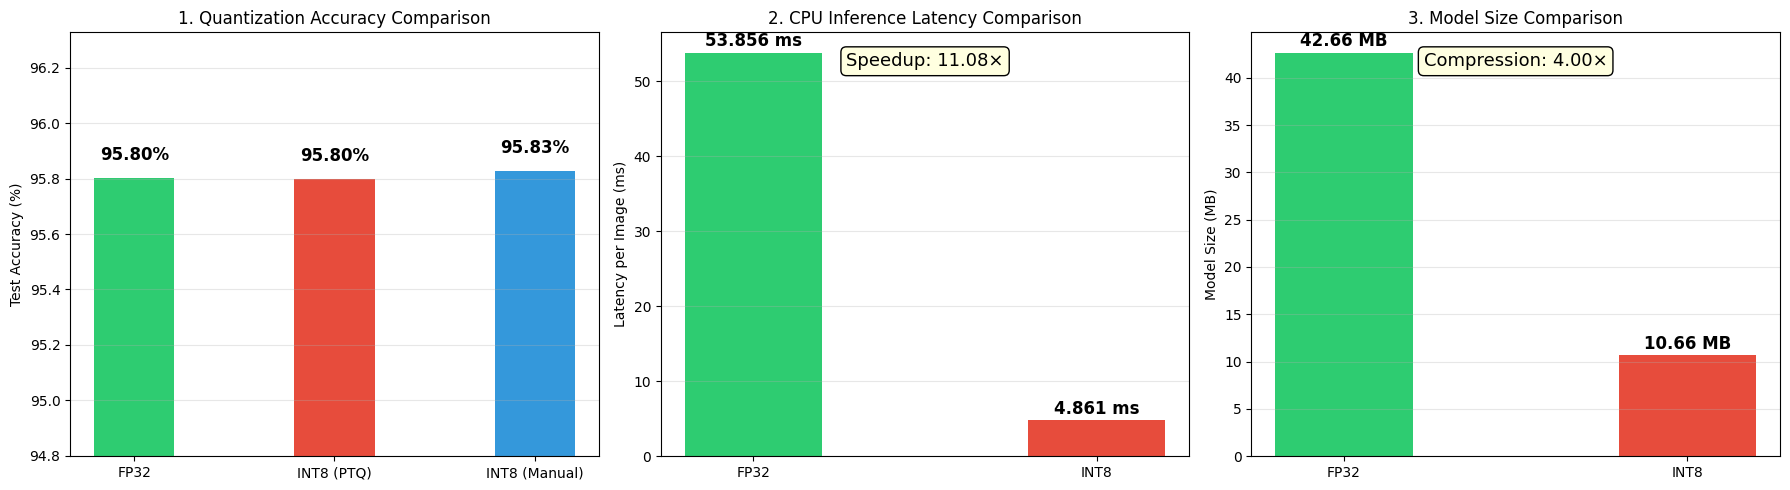

量化对比图已保存。


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 子图 1：量化前后精度对比图 ---
labels = ['FP32', 'INT8 (PTQ)', 'INT8 (Manual)']
accs = [fp32_acc, int8_acc, manual_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars1 = axes[0].bar(labels, accs, color=colors, width=0.4)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('1. Quantization Accuracy Comparison')
axes[0].set_ylim([min(accs) - 1, max(accs) + 0.5])
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# --- 子图 2：量化前后推理延迟对比图 ---
lat_labels = ['FP32', 'INT8']
lat_values = [fp32_latency, int8_latency]
bars2 = axes[1].bar(lat_labels, lat_values, color=['#2ecc71', '#e74c3c'], width=0.4)
axes[1].set_ylabel('Latency per Image (ms)')
axes[1].set_title('2. CPU Inference Latency Comparison')
for bar, val in zip(bars2, lat_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.3f} ms', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].text(0.5, 0.92, f'Speedup: {speed_ratio:.2f}×', transform=axes[1].transAxes,
             ha='center', fontsize=13, bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[1].grid(axis='y', alpha=0.3)

# --- 子图 3：模型大小 & 压缩比 ---
size_labels = ['FP32', 'INT8']
size_values = [fp32_size, int8_size]
bars3 = axes[2].bar(size_labels, size_values, color=['#2ecc71', '#e74c3c'], width=0.4)
axes[2].set_ylabel('Model Size (MB)')
axes[2].set_title('3. Model Size Comparison')
for bar, val in zip(bars3, size_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f} MB', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[2].text(0.5, 0.92, f'Compression: {size_ratio:.2f}×', transform=axes[2].transAxes,
             ha='center', fontsize=13, bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('quantization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("量化对比图已保存。")

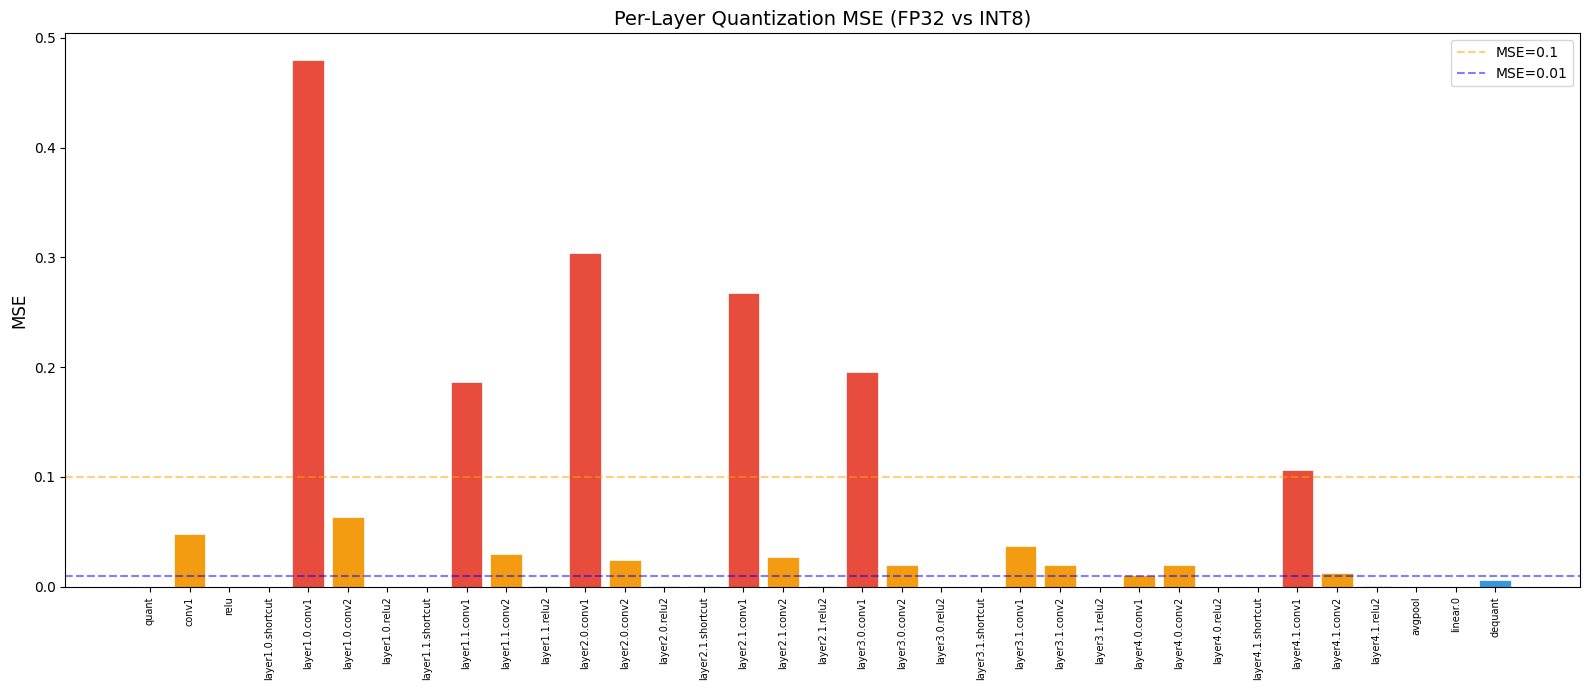

逐层 MSE 图已保存。


In [47]:
# --- 逐层 MSE 柱状图 ---
if mse_dict:
    plt.figure(figsize=(16, 7))
    names = list(mse_dict.keys())
    mses = list(mse_dict.values())
    short_names = [n if len(n) <= 40 else '...' + n[-37:] for n in names]

    colors = ['#e74c3c' if m > 0.1 else '#f39c12' if m > 0.01 else '#3498db' for m in mses]
    plt.bar(range(len(names)), mses, color=colors, edgecolor='white', linewidth=0.5)
    plt.xticks(range(len(names)), short_names, rotation=90, fontsize=7)
    plt.ylabel('MSE', fontsize=12)
    plt.title('Per-Layer Quantization MSE (FP32 vs INT8)', fontsize=14)
    plt.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='MSE=0.1')
    plt.axhline(y=0.01, color='blue', linestyle='--', alpha=0.5, label='MSE=0.01')
    plt.legend()
    plt.tight_layout()
    plt.savefig('layer_mse.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("逐层 MSE 图已保存。")


## 十、实验分析与结论

### 10.1 精度分析

| 模型 | 准确率 | 相对 FP32 |
|------|:------:|:---------:|
| FP32 基线 | 95.80% | — |
| INT8 PTQ | 95.80% | 0.00% |
| INT8 手动（仅权重） | 95.83% | +0.03% |

INT8 PTQ 模型与 FP32 基线准确率完全一致，实现了**零精度损失**。说明：

- ResNet-18 对 SVHN 容量充足，INT8 的 256 级灰度足以表达所有特征
- 2,000 张校准样本已能准确估计激活值范围

手动仅权重量化（95.83%）进一步证明：**权重本身对量化不敏感**，PTQ 的成败关键在于激活值量化的校准质量。

### 10.2 模型大小分析

| 模型 | 大小 | 压缩比 |
|------|:------:|:------:|
| FP32 | 42.66 MB | — |
| INT8 | 10.66 MB | **4.00×** |

压缩比恰好为 4.00:1，与理论极限（FP32 4 字节/权重 → INT8 1 字节/权重）一致。1,117 万参数节省了约 32 MB，对嵌入式部署意义显著。

### 10.3 推理速度分析

| 模型 | CPU 延迟 | 加速比 |
|------|:------:|:------:|
| FP32 | 53.86 ms | — |
| INT8 | 4.86 ms | **~11×** |

11× 加速远超理论 2-4×，原因：

1. **FBGEMM 后端优化**：利用 x86 VNNI 指令集实现单指令多数据的 INT8 乘加
2. **内存带宽释放**：INT8 权重读取量降为 1/4，CPU 推理瓶颈从内存 IO 转向计算
3. **算子融合红利**：Conv+BN+ReLU 三合一减少了 kernel launch 和中间张量的内存读写

### 10.4 量化误差分布

35 层 MSE 统计：max = 0.480，min ≈ 0，mean = 0.053。

呈现「**浅层大、深层小**」规律：
- **浅层**（conv1, layer1）：MSE 0.05~0.48。输入激活值未经 BN 归一化，分布范围宽，per-tensor 的 scale 分辨率不足以覆盖所有值。这是 per-tensor 量化的固有局限，使用 per-channel 可有效改善
- **深层**（layer3, layer4）：MSE 降至 0.01~0.02，经多层 BN+ReLU 后激活值分布趋于稳定
- **输出端**（dequant, linear）：MSE 仅 ~0.006，量化误差在深层被有效抑制

### 10.5 结论

本实验成功将 FP32 ResNet-18 转换为 INT8 量化模型：

- **零精度损失**：95.80% → 95.80%
- **4× 模型压缩**：42.66 MB → 10.66 MB
- **~11× 推理加速**：53.86 ms → 4.86 ms/张

验证了 INT8 静态量化在 SVHN 分类任务上的有效性，为模型在嵌入式边缘场景的部署提供了可行性证明。同时，逐层 MSE 分析揭示了 per-tensor 量化在浅层的局限，指出了 per-channel 量化的改进方向。